# **Energy consumption Prediction Using - XGboos Time series analysis**

### Importing Important Dependencies 

In [1]:
# Essential Libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

col_pal = sns.color_palette()

# Model Importing 
import xgboost as xgb

## Data collection

In [2]:
df = pd.read_csv(r'D:\Robotics\Machine Learning Projects\XGboost Based Energy Consumption prediction\data\PJME_hourly.csv')
df=df.set_index('Datetime')



In [3]:
pd.to_datetime(df.index)

DatetimeIndex(['2002-12-31 01:00:00', '2002-12-31 02:00:00',
               '2002-12-31 03:00:00', '2002-12-31 04:00:00',
               '2002-12-31 05:00:00', '2002-12-31 06:00:00',
               '2002-12-31 07:00:00', '2002-12-31 08:00:00',
               '2002-12-31 09:00:00', '2002-12-31 10:00:00',
               ...
               '2018-01-01 15:00:00', '2018-01-01 16:00:00',
               '2018-01-01 17:00:00', '2018-01-01 18:00:00',
               '2018-01-01 19:00:00', '2018-01-01 20:00:00',
               '2018-01-01 21:00:00', '2018-01-01 22:00:00',
               '2018-01-01 23:00:00', '2018-01-02 00:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=145366, freq=None)

In [4]:
df.index = pd.to_datetime(df.index)

In [5]:
df.head()

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


In [6]:
df.tail()

,PJME_MW
Datetime,
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0
2018-01-01 23:00:00,40164.0
2018-01-02 00:00:00,38608.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145366 entries, 2002-12-31 01:00:00 to 2018-01-02 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB


In [8]:
df.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [9]:
df.isnull().sum()

PJME_MW    0
dtype: int64

From Above we can see there is no missing values in this dataset so the cleaning process is reduced

## Data Visualization

<Axes: title={'center': 'Energy Consumption in MW'}, xlabel='Datetime'>

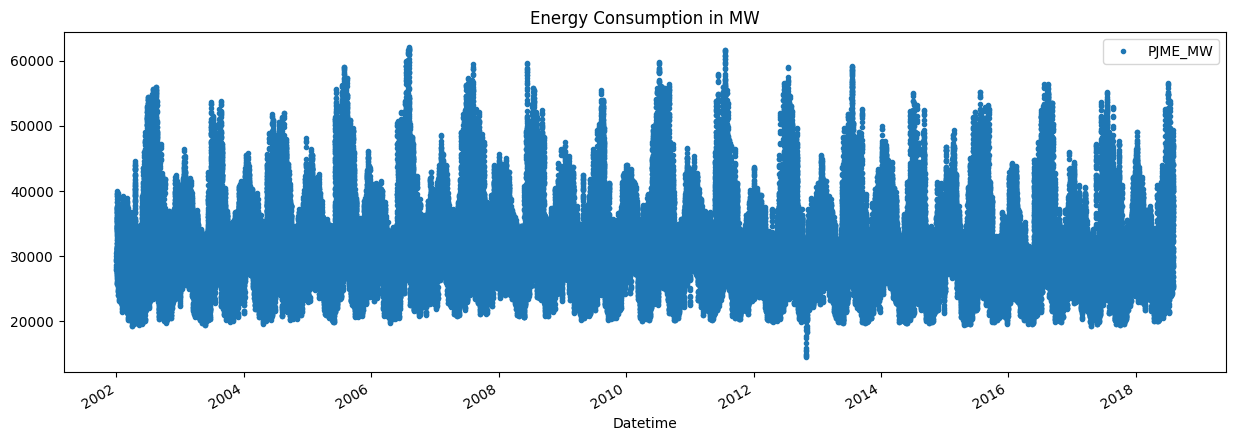

In [10]:
df.plot(style='.',
        figsize=(15,5),
        color = col_pal[0],
        title='Energy Consumption in MW')

## Train / Test Split

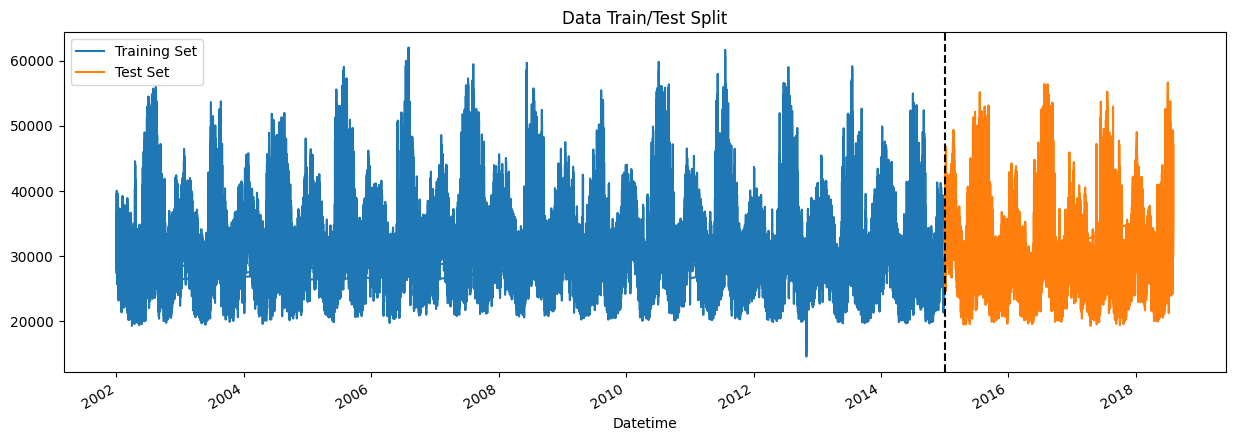

In [11]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index > '01-01-2015']
fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

In [17]:
train.tail()

,PJME_MW
Datetime,
2014-01-01 20:00:00,36193.0
2014-01-01 21:00:00,35601.0
2014-01-01 22:00:00,34242.0
2014-01-01 23:00:00,32215.0
2014-01-02 00:00:00,30159.0


In [16]:
test.head()

,PJME_MW
Datetime,
2015-12-31 01:00:00,24305.0
2015-12-31 02:00:00,23156.0
2015-12-31 03:00:00,22514.0
2015-12-31 04:00:00,22330.0
2015-12-31 05:00:00,22773.0


In [15]:
test.tail()

,PJME_MW
Datetime,
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0
2018-01-01 23:00:00,40164.0
2018-01-02 00:00:00,38608.0


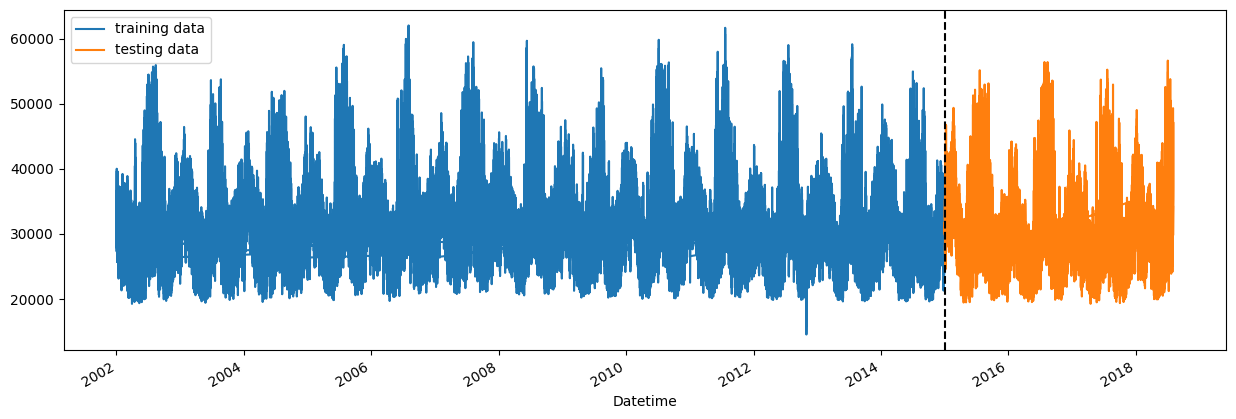

In [14]:
fig , ax = plt.subplots(figsize = (15,5))
train.plot(ax = ax,label ='Training set')
test.plot(ax =ax ,label ='Test set')
ax.axvline('01-01-2015',color = 'black',ls = '--')
ax.legend(['training data','testing data'])
plt.show()

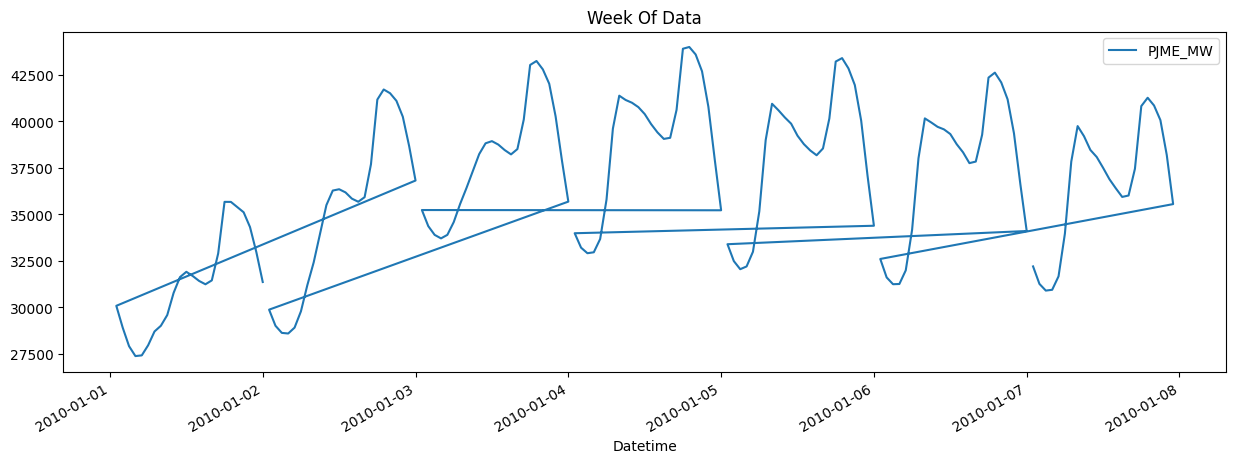

In [30]:
# Plotting data of the week 

df.loc[(df.index > '01-01-2010') & (df.index < '01-08-2010')] \
    .plot(figsize=(15, 5), title='Week Of Data')
plt.show()


## Feature Creation

In [ ]:
df.drop(columns='dayOfWeek')


,PJME_MW,hour,dayofweek
Datetime,,,
2002-12-31 01:00:00,26498.0,1,1
2002-12-31 02:00:00,25147.0,2,1
2002-12-31 03:00:00,24574.0,3,1
2002-12-31 04:00:00,24393.0,4,1
2002-12-31 05:00:00,24860.0,5,1
...,...,...,...
2018-01-01 20:00:00,44284.0,20,0
2018-01-01 21:00:00,43751.0,21,0
2018-01-01 22:00:00,42402.0,22,0


In [51]:

df=df.drop(columns='dayOfWeek')

In [52]:
df

,PJME_MW,hour
Datetime,,
2002-12-31 01:00:00,26498.0,1
2002-12-31 02:00:00,25147.0,2
2002-12-31 03:00:00,24574.0,3
2002-12-31 04:00:00,24393.0,4
2002-12-31 05:00:00,24860.0,5
...,...,...
2018-01-01 20:00:00,44284.0,20
2018-01-01 21:00:00,43751.0,21
2018-01-01 22:00:00,42402.0,22


In [53]:
df=df.drop(columns='hour')

In [ ]:
# Function to create features 

def feature_creation(df):

    """
    Create time series features based on time series index.
    """

    df['hour']= df.index.hour
    df['dayofweek']=df.index.dayofweek
    df['year']=df.index.year
    df['month']=df.index.month
    df['quarter']=df.index.quarter
    df['dayofyear']=df.index.dayofyear
    return df

In [56]:
df = feature_creation(df)

In [57]:
df

,PJME_MW,hour,dayofweek,year,month,quarter,dayofyear
Datetime,,,,,,,
2002-12-31 01:00:00,26498.0,1,1,2002,12,4,365
2002-12-31 02:00:00,25147.0,2,1,2002,12,4,365
2002-12-31 03:00:00,24574.0,3,1,2002,12,4,365
2002-12-31 04:00:00,24393.0,4,1,2002,12,4,365
2002-12-31 05:00:00,24860.0,5,1,2002,12,4,365
...,...,...,...,...,...,...,...
2018-01-01 20:00:00,44284.0,20,0,2018,1,1,1
2018-01-01 21:00:00,43751.0,21,0,2018,1,1,1
2018-01-01 22:00:00,42402.0,22,0,2018,1,1,1


## Visualize feature and target relationship 